In [30]:
import numpy as np
from matplotlib import pyplot as plt
# import modred as mr
import matplotlib.pylab as pylab
# import scipy.io as sio
from matplotlib.ticker import FuncFormatter
from matplotlib.colors import ListedColormap

params={
    'axes.labelsize'  : '24' ,
    'axes.linewidth' : '1.2' ,
    'axes.labelweight': 'bold' ,
#    'font.weight':  'bold' , 
#    'axes.labelcolor':    'red',
# x axis
    'xtick.direction' : 'in' ,
    'xtick.major.size' : '7' ,
    'xtick.major.width' : '1.25' ,
    'xtick.minor.size' : '4.43' ,
    'xtick.minor.width' : '1.25' ,
    'xtick.minor.visible' : 'True' ,
    'xtick.top' : 'True' ,
    'xtick.labelsize' : '24' ,
    'xtick.major.pad' : '10' ,

 #y axis
    'ytick.direction' : 'in' ,
    'ytick.major.size' : '7' ,
    'ytick.major.width' : '1.25' ,
    'ytick.minor.size' : '4.43' ,
    'ytick.minor.width' : '1.25' ,
    'ytick.minor.visible' : 'True' ,
    'ytick.right' : 'True' ,
    'ytick.labelsize' : '24' ,
    'ytick.major.pad' : '10' ,

    'lines.linewidth' : '3.3' ,
#legend
    'legend.fontsize' : '22' ,
    'legend.frameon' : 'False',
    'figure.figsize'    : '8, 8',

#Figure layout
#    'figure.autolayout' : 'True' ,
    'figure.subplot.left':   '0.13 ', # the left side of the subplots of the figure
    'figure.subplot.right':  '0.95',   # the right side of the subplots of the figure
    'figure.subplot.bottom': '0.13',   # the bottom of the subplots of the figure
    'figure.subplot.top':    '0.95',   # the top of the subplots of the figure

##font size
#    'font.size' : '50',

# Use LaTeX for math formatting
    'text.usetex' : 'True',
    'text.latex.preamble' : r'\usepackage{amsmath}',
    'text.latex.preamble' : r'\usepackage{bm}'
}
pylab.rcParams.update(params)

15.70900487316899


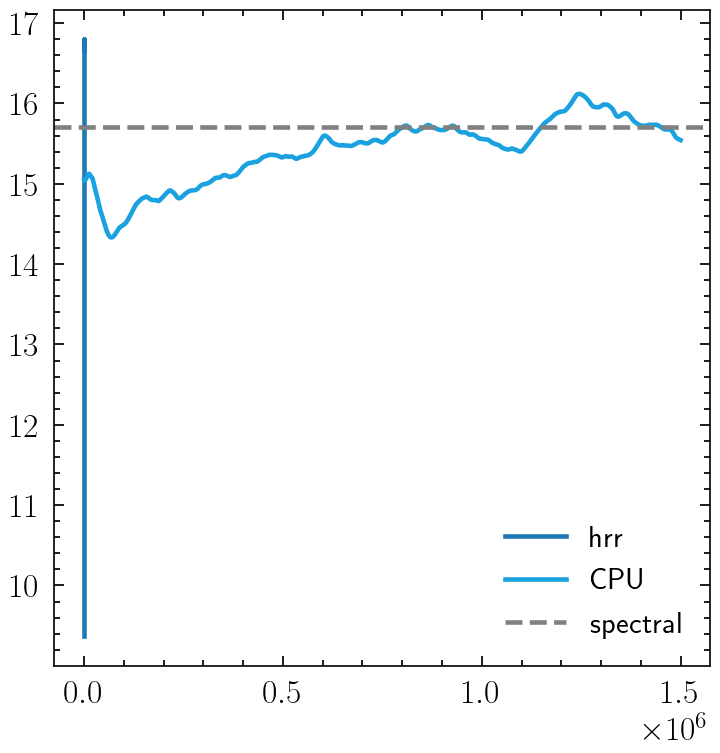

In [37]:
data = np.loadtxt('data/statistics.dat')
datastatrr66 = np.loadtxt('cpu/diag.dat')
# dataBB = np.loadtxt('data_BB/statistics.dat')
nx = 64
ny = 64
nz = 64
H = 32
pi = np.pi; Re = 180.0; visc = 0.000622
u0 = Re*visc/H
ystar = visc / u0
plt.plot(data[:,0]*u0/H,data[:,1]/u0, label = "hrr")
plt.plot(datastatrr66[:,0], datastatrr66[:,6], color='#19A2DF',label='CPU')

print(np.mean(data[-3000:,1]/u0))
# plt.plot(dataBB[:,0]*u0/H,dataBB[:,1]/u0, label = "BB")
# plt.scatter(data[:,0]*u0/H,data[:,1]/u0,label = 'RR-LES',s=10)
plt.axhline(y=15.708, color='grey', linestyle='--', label='spectral')
plt.legend()
# plt.xlim(0,25)
nvars = 4
istep      = 100000
file_start = 100000
file_end   = 100000
file_step  = 34000


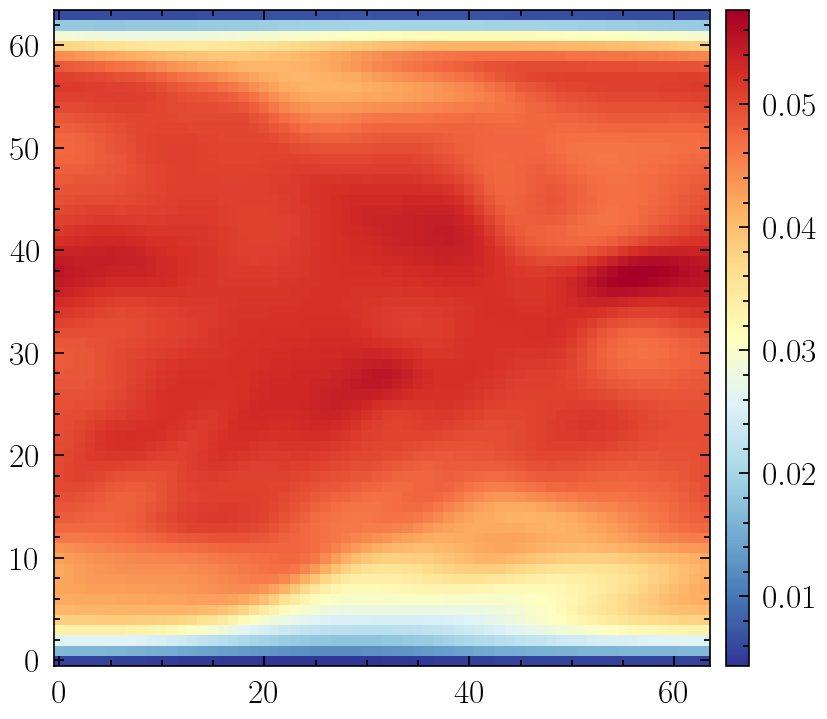

In [32]:
def add_colorbar(im, width=None, pad=0.02, **kwargs):
    l, b, w, h = im.axes.get_position().bounds       # get boundaries
    width = width or 0.035 * w                       # get width of the colorbar
    pad = pad or width                               # get pad between im and cbar
    fig = im.axes.figure                             # get figure of image
    cax = fig.add_axes([l + w + pad, b, width, h])   # define cbar Axes<br/>    
    return fig.colorbar(im, cax=cax, **kwargs)       # draw cbar

dir = 'data/'

nvariables = 4
nxyz = nx*ny*nz
# nsteps = 30

count = 0
finameu = f"{dir}{istep:09d}.dat"
# print(finameu)

# read ux
field = np.fromfile(finameu, dtype='float64')
data = field.reshape(nx, ny, nz, nvariables, order ='F')

data_rho = data[:,:,:, 0]
data_u   = data[:,:,:, 1]
data_v   = data[:,:,:, 2]
data_w   = data[:,:,:, 3]
# data_phi = data[:,:,:, 4]
# data_ted = data[:,:,:, 5]
# data_ked = data[:,:,:, 6]

# extract a slice
data_u_plt   = data_u[:,:, 16]
data_v_plt   = data_v[:,:, 16]
data_w_plt   = data_w[:,:, 16]
# print(data_u_plt[2,:]/u0)
# print(data_u_plt[:,1])
# print(data_u_plt[:,62])
# print(data_u_plt[:,63])

# calculate the velocity magnitude
# datauv = data_u_plt**2.+  data_v_plt**2. + data_w_plt**2.
# print(datauv.shape)

uw = 0.1
# Grid Mesh
Y, X = np.mgrid[1:nx:ny*1j, 1:nx:ny*1j]
Y = Y - 0.5; X = X - 0.5

im = plt.imshow(data_u_plt.T, origin='lower', cmap = 'RdYlBu_r')
# plt.streamplot(X, Y, data_u_plt.T, data_v_plt.T, density = 1.5, \
#                linewidth = 0.5, color='black', broken_streamlines=False)
# plt.quiver(X[::5,::5], Y[::5,::5], data_u.T[::5,::5]/uw, data_v.T[::5,::5]/uw, scale = 10)
# plt.xticks([0, 360, 720],['0', '0.5', '1.0'] )
# plt.yticks([0, 360, 720],['0', '0.5', '1.0'] )
# plt.xlim(0, nx)
# plt.ylim(0, nx)
add_colorbar(im)
plt.show()

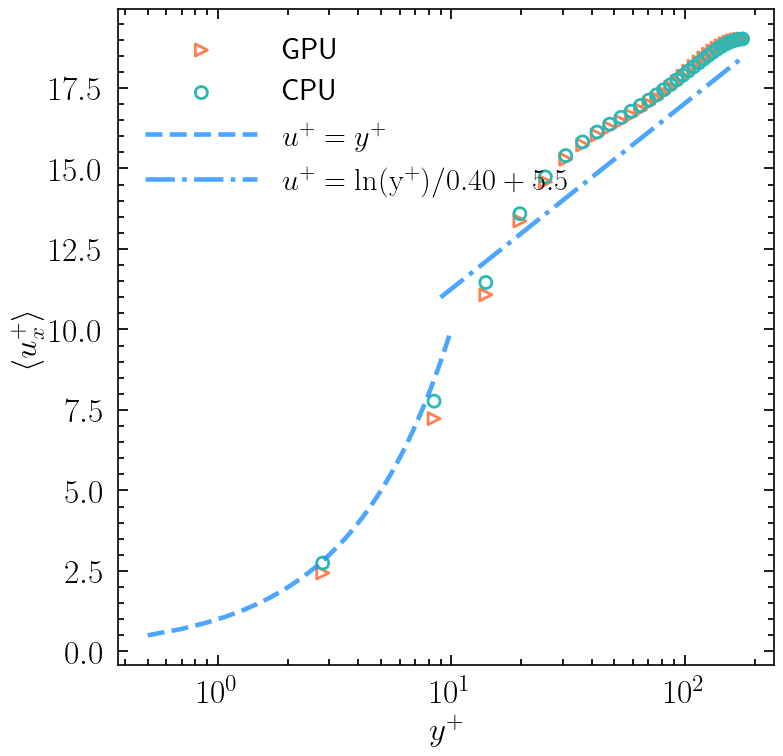

In [33]:
datapro = np.loadtxt('profile_forplt_.txt')
dataprocpu = np.loadtxt('profile_forplt_RR33.txt')

x1 = np.linspace(0.5,10,50)
y1 = x1
x2 = np.linspace(9,180,50)
y2 = np.log(x2)/0.40 + 5.5

# uymean = np.zeros(ny)
# for i in range (0, ny):
#     uymean[i] = np.mean(data_u[:,i,:])

# plt.scatter((datapro[0:H, 1]*ystar + 0.5) / ystar, datapro[0:H,2]/u0,color='none', marker='>', edgecolors='coral', \
plt.scatter((datapro[0:H, 1]), datapro[0:H,2]/u0,color='none', marker='>', edgecolors='coral', \
    s=75, linewidths = 2.0, label='GPU')
plt.scatter(dataprocpu[0:H, 1], dataprocpu[0:H,3],color='none', marker='o', edgecolors='#2bb7b3', \
    s=75, linewidths = 2.0, label='CPU')
plt.plot(x1, y1,c='dodgerblue',linestyle='--', alpha =0.8, label=r'$u^+=y^+$')
plt.plot(x2, y2,c='dodgerblue',linestyle='-.', alpha =0.8, label=r'$u^+=\rm{ln}(y^+)/0.40+5.5$')
plt.xscale("log")
plt.xlabel(r'$y^+$')
plt.ylabel(r'$\langle u_x^+\rangle$')
#plt.xlim(-4, 4)
# plt.ylim(0, 24)
plt.legend(handlelength = 3.66)

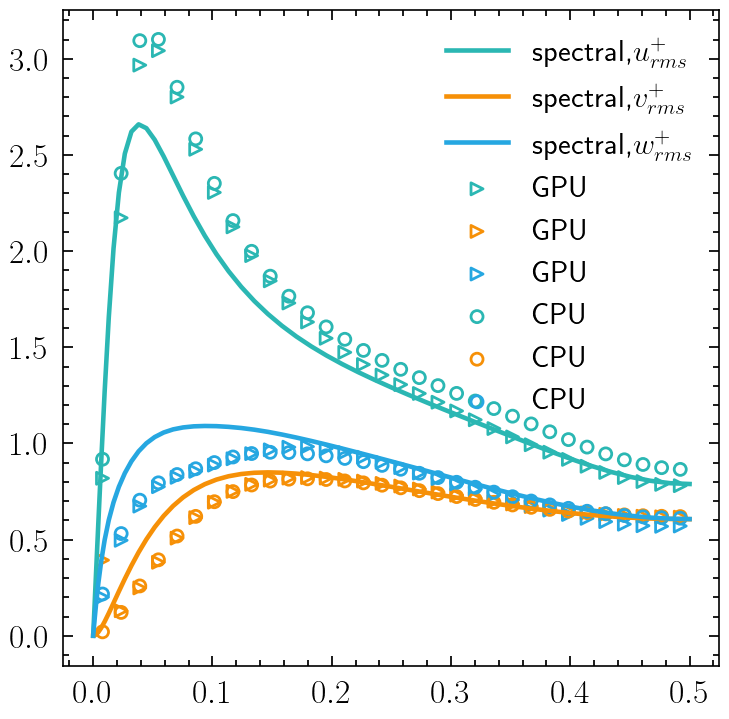

In [34]:
dataspec = np.loadtxt('Re180.prof')
yspec = dataspec[:,0] / 2
uspec = dataspec[:,3]
vspec = dataspec[:,4]
wspec = dataspec[:,5]
plt.plot(yspec, uspec,color = '#2BB7B3',label = r'spectral,$u^+_{rms}$')
plt.plot(yspec, vspec,color = '#F69007',label = r'spectral,$v^+_{rms}$')
plt.plot(yspec, wspec,color = '#26A7E1',label = r'spectral,$w^+_{rms}$')

y = datapro[0:H,0]/ny
urms = np.sqrt(datapro[0:H,5]/u0/u0)
vrms = np.sqrt(datapro[0:H,6]/u0/u0)
wrms = np.sqrt(datapro[0:H,7]/u0/u0)
plt.scatter(y,urms,edgecolors = '#2BB7B3', marker='>', facecolors='none', s=75,linewidths=2, label='GPU')
plt.scatter(y,vrms,edgecolors = '#F69007', marker='>', facecolors='none', s=75,linewidths=2, label='GPU')
plt.scatter(y,wrms,edgecolors = '#26A7E1', marker='>', facecolors='none', s=75,linewidths=2, label='GPU')

yFD = (dataprocpu[0:H,0])/ny
urmsFD = np.sqrt(dataprocpu[0:H,6])
vrmsFD = np.sqrt(dataprocpu[0:H,5])
wrmsFD = np.sqrt(dataprocpu[0:H,7])
plt.scatter(yFD,urmsFD,edgecolors = '#2BB7B3',marker='o', facecolors='none', s=75,linewidths=2, label='CPU')
plt.scatter(yFD,vrmsFD,edgecolors = '#F69007',marker='o', facecolors='none', s=75,linewidths=2, label='CPU')
plt.scatter(yFD,wrmsFD,edgecolors = '#26A7E1',marker='o', facecolors='none', s=75,linewidths=2, label='CPU')

plt.legend()
# plt.plot(y,vrms)
# plt.plot(y,wrms)

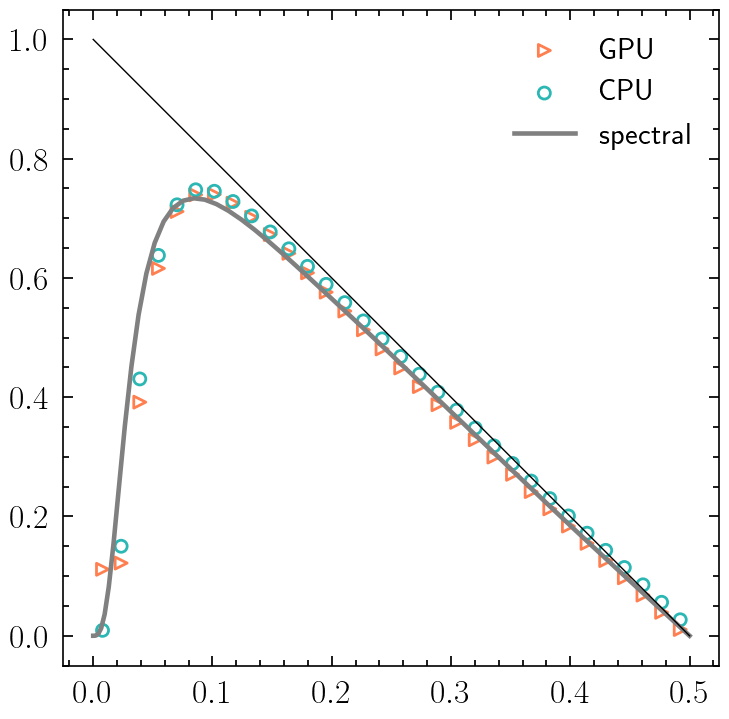

In [35]:
res = -(datapro[0:H,8] / u0/u0)
resFD = -(dataprocpu[0:H,9])
resspc = dataspec[:,9]

plt.scatter(y,res,edgecolors = 'coral', marker='>',facecolors='none', s=75,linewidths=2,label='GPU')
plt.scatter(y,resFD,edgecolors = '#2BB7B3', marker='o',facecolors='none', s=75,linewidths=2,label='CPU')

# plt.scatter(y_top,res_top, marker = 'o', edgecolors = '#2BB7B3', facecolors='none', s=75,linewidths=2,label='RR-LES')

plt.plot(yspec, -dataspec[:,10],color='grey',label='spectral')

plt.plot([0, 0.5], [1, 0], color='black', linestyle='-', linewidth=1)      
plt.legend()
# plt.plot(y,vrms)
# plt.plot(y,wrms)